# Machine Learning for CICY 4-folds

Following the analysis in [arXiv:2007.13379](http://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](http://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds. The idea is to see whether the Inception network can also be applied in higher dimensions.

## Inference Analysis

In this notebook we deal with the prediction of the Hodge numbers using artificial neural networks (ANN).

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from mltools import *
import json

ctx = Context(img_dir='img',
              log_dir='log',
              dat_dir='data',
              mod_dir='models',
              tensorboard='tboard',
              session='ann_inference',
              subdir=True,
              gpu_ready=True
             )
log     = ctx.logger()
mod_dir = ctx.mod()
tb_dir  = ctx.tboard()

random_state = 456
np.random.seed(random_state)
tf.random.set_seed(random_state)

log.info('ANN Inference Analysis.')

GPU is ready!


## Read the Dataset

We read the dataset from its [URL](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_matrix.json.gz) and display basic information.

In [2]:
tab                  = Table('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_matrix.json.gz', ctx=ctx).read(orient='index')
df, (n_rows, n_cols) = tab.data()
log.debug(f'Dataset: {n_rows:d} rows X {n_cols:d} columns')

No. of rows:    905684.
No. of columns: 5.


We then extract the shape of the matrix before proceeding:

In [3]:
shape = df['matrix'].apply(lambda m: np.shape(m)).max()
log.debug(f'Shape of the configuration matrix {shape}.')

## Train and Test Folds

We then split the dataset into training, validation and test folds for evaluation.

In [4]:
splits = {'train':      0.1,
          'validation': 0.1,
          'test':       0.1,
          'stratified': 'h21'
         }
with open(os.path.join(mod_dir, 'splits.json'), 'w') as f:
    json.dump(splits, f)

train, val, test = df.eda.train_test_split(random_state=random_state, ctx=ctx, **splits)
log.info(f'Train ratio: {100 * train.shape[0] / n_rows:.3f}%.')
log.info(f'Validation ratio: {100 * val.shape[0] / n_rows:.3f}%.')
log.info(f'Test ratio: {100 * test.shape[0] / n_rows:.3f}%.')

Training set:   90571 rows (10.0% ratio)
Test set:        89662 rows (9.9% ratio)
Validation set: 87053 rows (9.6% ratio)


We then need to separate features and labels:

In [5]:
X_train, y_train = train.eda.feat_lab('matrix', ['h11', 'h21', 'h31', 'h22'], to_dict=True)
X_val,   y_val   = val.eda.feat_lab('matrix', ['h11', 'h21', 'h31', 'h22'], to_dict=True)
X_test,  y_test  = test.eda.feat_lab('matrix', ['h11', 'h21', 'h31', 'h22'], to_dict=True)

We finally reshape the inputs for the convolutions:

In [6]:
old_shape = np.shape(X_train['matrix'])[1:]

X_train['matrix'] = np.reshape(X_train['matrix'], (-1,) + old_shape + (1,))
X_val['matrix']   = np.reshape(X_val['matrix'], (-1,) + old_shape + (1,))
X_test['matrix']  = np.reshape(X_test['matrix'], (-1,) + old_shape + (1,))

We also duplicate the labels for the auxiliary output, when needed:

In [7]:
y_train.update({key + '_aux': value for key, value in y_train.items()})
y_val.update({key + '_aux': value for key, value in y_val.items()})
y_test.update({key + '_aux': value for key, value in y_test.items()})

## Model Architectures

We finally choose the model architectures suitable for the prediction.

In [8]:
parameters = {'input_shape':         X_train['matrix'].shape[1:],
              'name':                'matrix',
              'learning_rate':       1.0e-2,
              'output_names':        ['h11', 'h21', 'h31', 'h22'],
              'output_size':         [1, 1, 1, 1],
              'model_type':          'regression',
              'inception_kernel':    'vertical',
              'conv_1b1':            False,
              'conv_layers':         [32, 64, 32],
              'conv_alpha':          0.0,
              'conv_class':          None,
              'conv_single':         False,
              'conv_red':            0,
              'feat_map':            0,
              'recurrent':           False,
              'fc_layers':           [],
              'fc_alpha':            0.0,
              'dropout':             0.2,
              'full_dropout':        0.0,
              'batchnorm':           0.99,
              'last_relu':           True,
              'loss_weights':        [0.3, 0.3, 0.2, 0.2],
              'l1_reg':              1.0e-3,
              'l2_reg':              1.0e-3,
              'auxiliary_fc':        [10, 5],
              'auxiliary_last_relu': True,
              'auxiliary_suff':      'aux',
              'output_layers':       True,
              'random_state':        random_state
             }

param_file = os.path.join(mod_dir, 'ann_parameters.json')
with open(param_file, 'w') as f:
    json.dump(parameters, f)
    log.debug(f'ANN parameters saved to {param_file}.')
    
model = InceptionDNN(**parameters)

We then take a look at the summary of the model:

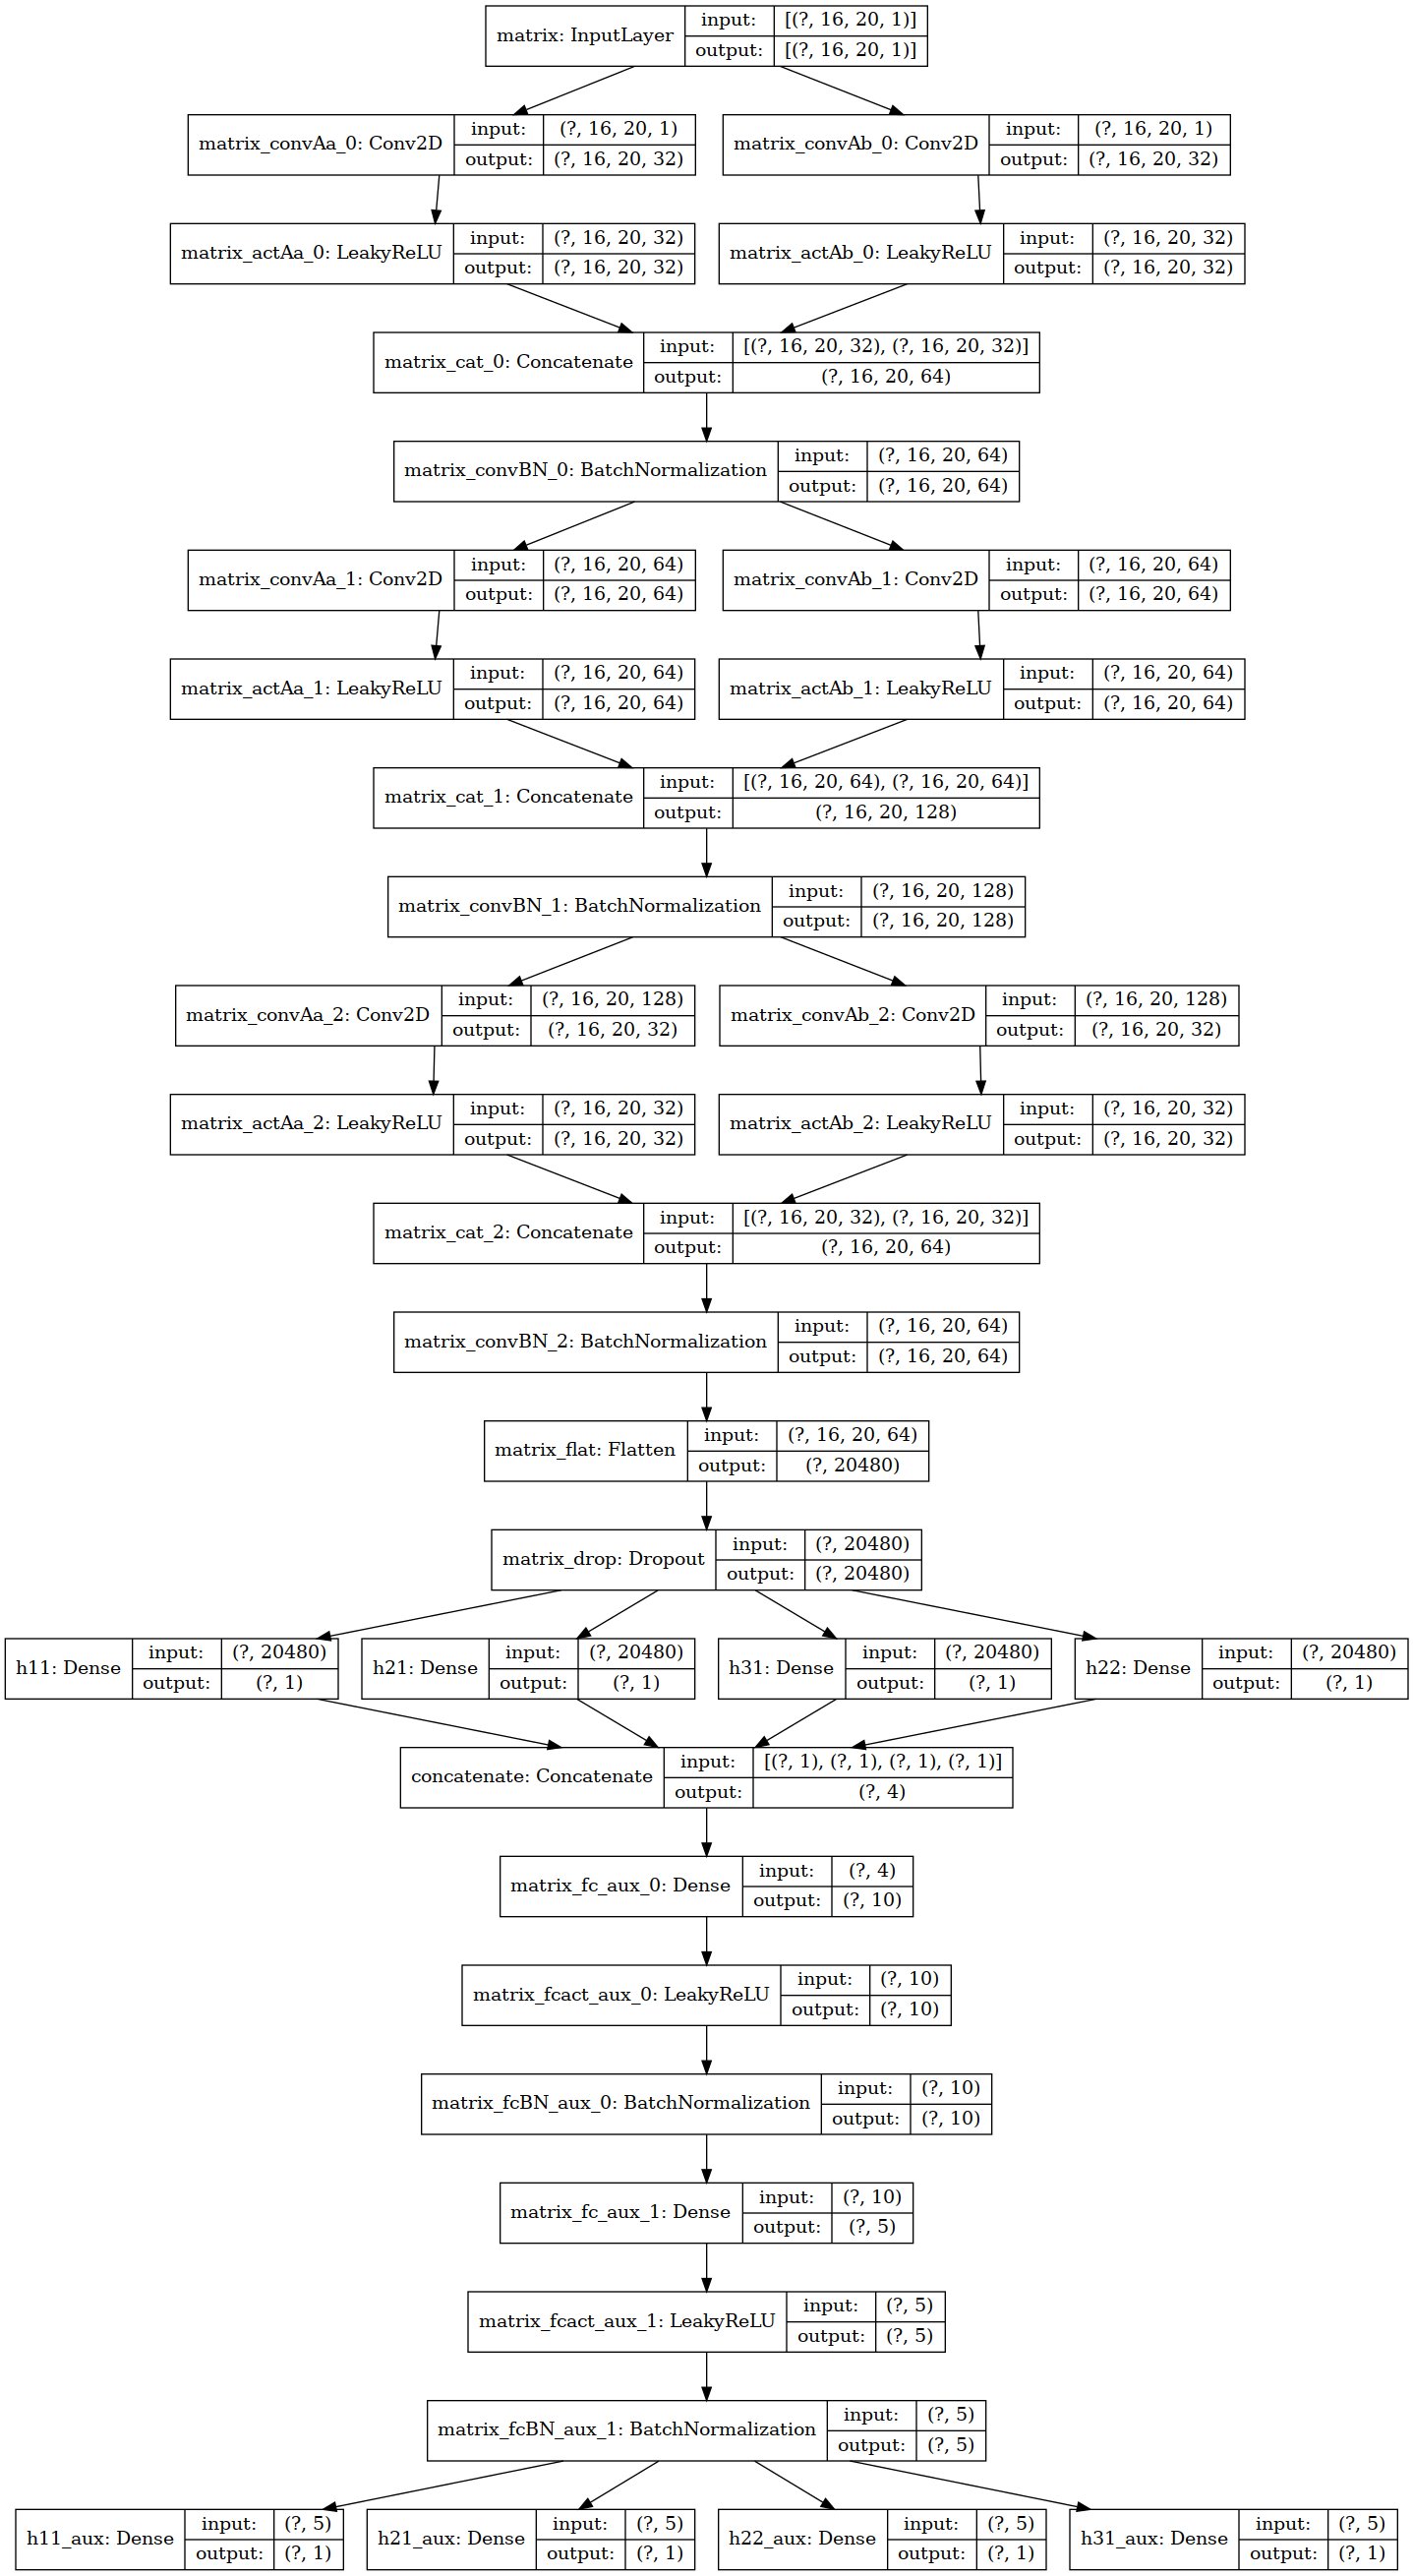

In [9]:
keras.utils.plot_model(model, to_file=os.path.join(ctx.img(), 'architecture.png'), show_shapes=True)

In [10]:
model.summary()

Model: "matrix"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
matrix_convAa_0 (Conv2D)        (None, 16, 20, 32)   544         matrix[0][0]                     
__________________________________________________________________________________________________
matrix_convAb_0 (Conv2D)        (None, 16, 20, 32)   672         matrix[0][0]                     
__________________________________________________________________________________________________
matrix_actAa_0 (LeakyReLU)      (None, 16, 20, 32)   0           matrix_convAa_0[0][0]            
_____________________________________________________________________________________________

We then fit the model on the training set:

In [11]:
fit_params = {'epochs':      150,
              'batch_size':  32,
              'reduce_lr':   0.3,
              'lr_patience': 60
             }

param_file = os.path.join(mod_dir, 'fit_parameters.json')
with open(param_file, 'w') as f:
    json.dump(fit_params, f)
    log.debug(f'Fit parameters saved to {param_file}.')

# create callbacks
callbacks  = model_checkpoints(outputs=['h11', 'h21', 'h31', 'h22'],
                               root=mod_dir,
                               reduce_lr=fit_params['reduce_lr'],
                               lr_patience=fit_params['lr_patience'],
                               summary=fit_params['epochs'] / 15,
                               tensorboard=tb_dir
                              )

log.info('Begin training Inception ANN...')
history = model.fit(x=X_train,
                    y=y_train,
                    batch_size=fit_params['batch_size'],
                    epochs=fit_params['epochs'],
                    callbacks=callbacks,
                    validation_data=(X_val, y_val),
                    verbose=False
                   )

Training has started. Callouts will be printed every 10 epochs.

Training epoch 1. Started on 01/02/2021 at 11:01:45.

    Average epoch training time: 00 hours, 02 minutes, 05 seconds

    loss = 1884.728516
    h11_loss = 108.352859
    h11_aux_loss = 11.102414
    h21_loss = 4.252983
    h21_aux_loss = 3.607531
    h22_loss = 844.238708
    h22_aux_loss = 6378.727539
    h31_loss = 1746.218506
    h31_aux_loss = 132.788193
    h11_mean_squared_error = 108.352859
    h11_mean_absolute_error = 10.087337
    h11_aux_mean_squared_error = 11.102414
    h11_aux_mean_absolute_error = 2.119864
    h21_mean_squared_error = 4.252983
    h21_mean_absolute_error = 0.820092
    h21_aux_mean_squared_error = 3.607531
    h21_aux_mean_absolute_error = 1.143235
    h22_mean_squared_error = 844.238708
    h22_mean_absolute_error = 18.316988
    h22_aux_mean_squared_error = 6378.727539
    h22_aux_mean_absolute_error = 43.311703
    h31_mean_squared_error = 1746.218506
    h31_mean_absolute_error = 39

## Analysis of the Training

We consider the training history and perform a basic analysis of the loss function and the metrics as function of the training epochs.

/home/riccardo/documents/ml-cicy/ml-cicy-4folds/mltools/tables/feateng.py:8: UserWarning: registration of accessor <class 'mltools.tables.feateng.EDA'> under name 'eda' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  class EDA:


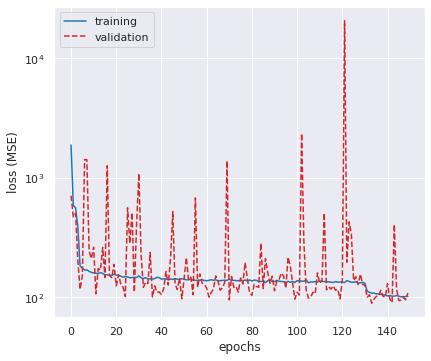

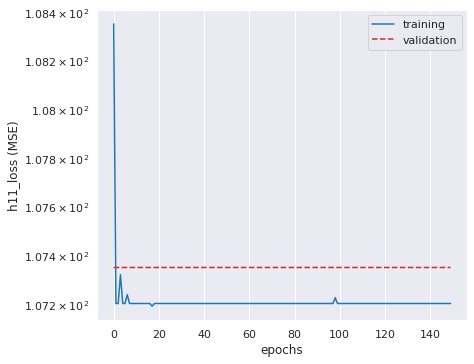

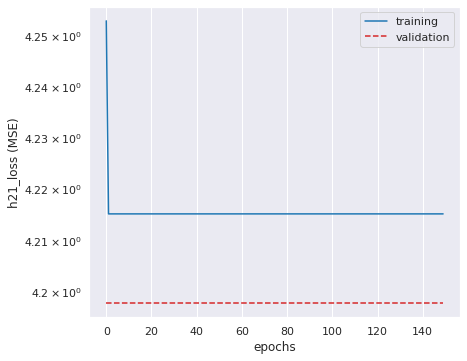

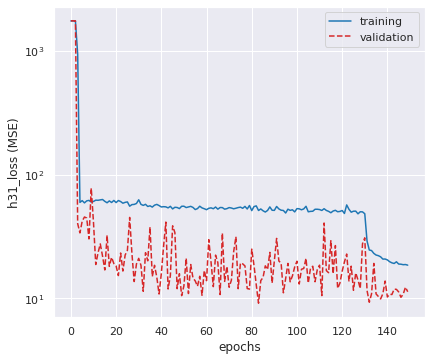

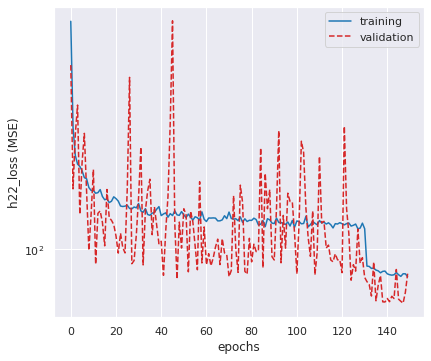

In [12]:
losses = ['loss', 'h11_loss', 'h21_loss', 'h31_loss', 'h22_loss']

loss_plots = {}
for loss in losses:
    
    loss_plots[loss] = TrainTestPlot(train=history.history[loss], validation=history.history['val_' + loss])
    loss_plots[loss].lineplot(logscale=(False,True), ylabel=loss + ' (MSE)', save=True, ctx=ctx, name=loss)

In order to understand the behaviour of the loss, we can also take a look at the learning rate:

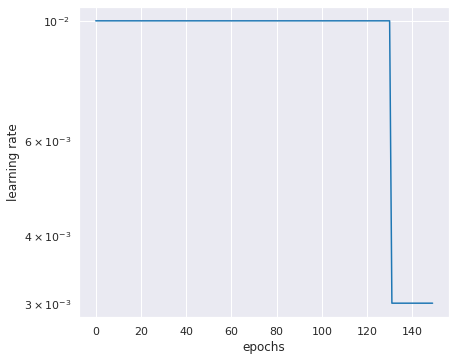

In [28]:
Plot(history.history,
     xlabel='epochs',
     ylabel='learning rate',
     logscale=(False,True),
     name='learning_rate',
     save=True,
     ctx=ctx
    ).lineplot(y='lr', series=True)

## Predictions

We finally compute metrics and predictions:

In [16]:
predictions = {}
data        = {'train_data': (X_train, y_train),
               'val_data':   (X_val, y_val),
               'test_data':  (X_test, y_test),
               'metric':     'acc',
               'func':       lambda x: np.rint(x).astype(int)
              }

predictions['full'] = Predictions(model=os.path.join(mod_dir, 'val_loss.h5'), **data)
predictions['h11']  = Predictions(model=os.path.join(mod_dir, 'val_h11_loss.h5'), **data)
predictions['h21']  = Predictions(model=os.path.join(mod_dir, 'val_h21_loss.h5'), **data)
predictions['h31']  = Predictions(model=os.path.join(mod_dir, 'val_h31_loss.h5'), **data)
predictions['h22']  = Predictions(model=os.path.join(mod_dir, 'val_h22_loss.h5'), **data)

We can then visualise the residuals in histograms:

TypeError: 'builtin_function_or_method' object is not subscriptable

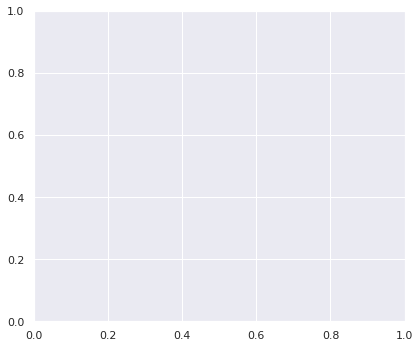

In [17]:
for lab in ['h11', 'h21', 'h31', 'h22']:
    predictions['full'].reshist(output=lab,
                                logscale=(False, True),
                                save=True,
                                xlabel=lab + ' residuals',
                                name='reshist_full_' + lab,
                                ctx=ctx
                               )

We can also visualise the scatter plots of the residuals:

In [ ]:
for lab in ['h11', 'h21', 'h31', 'h22']:
    predictions['full'].resplot(output=lab,
                                save=True,
                                xlabel=lab + ' predictions',
                                ylabel=lab + ' residuals',
                                name='resplot_full_' + lab,
                                ctx=ctx
                               )

We finally compute the metrics:

In [ ]:
for lab in ['h11', 'h21', 'h31', 'h22']:
    predictions['full'].metrics(output=lab, split='training', verbose=True, ctx=ctx)
    predictions['full'].metrics(output=lab, split='validation', verbose=True, ctx=ctx)
    predictions['full'].metrics(output=lab, split='test', verbose=True, ctx=ctx)

We eventually save the predictions to file:

In [ ]:
predictions['full'].get_metrics(to_file=os.path.join(mod_dir, 'metrics.json'));
predictions['full'].get_predictions(to_file=os.path.join(mod_dir, 'predictions.json'));
predictions['full'].get_residuals(to_file=os.path.join(mod_dir, 'residuals.json'));